# **EEEM066 - Fundamentals of Machine Learning**


# **Week - 6: Clustering and dimensionality reduction**

###

### Dr. Xiatian (Eddy) Zhu, Dr Syed Sameed Husain

xiatian.zhu@surrey.ac.uk, sameed.husain@surrey.ac.uk

**Introduction**
This lab is about the Clustering and dimensionality reduction. 

Clustering is the task of dividing the unlabeled data or data points into different clusters such that similar data points fall in the same cluster than those which differ from the others. In this lab we will cluster iris dataset using K-means clustering.

Dimensionality reduction, is the transformation of data from a high-dimensional space into a low-dimensional space so that the low-dimensional representation retains some meaningful properties of the original data, ideally close to its intrinsic dimension. In this lab we will reduce the dimensionality of cancer data using PCA.

**Contents**
1. K-means clustering
2. Principal Component Analysis

**Python libraries required**
1. Numpy
3. Matplotlib
4. Sklearn
5. Pandas

**Cluster data using k-means**


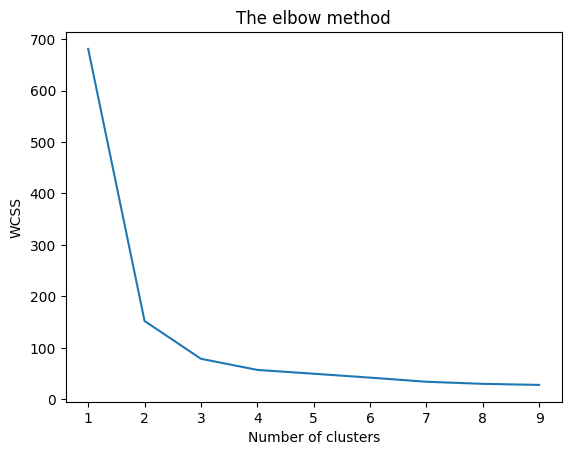

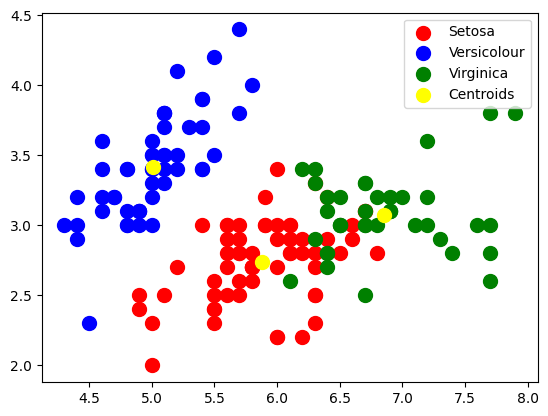

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn import datasets

## Load the dataset ##
iris = pd.read_csv('Week_6_iris_dataset.csv')

## To do the clustering we only need four features 
## (sepal length, sepal width, 
# petal length, and petal width)
x = iris.iloc[:, [1,2,3,4]]
x  = np.array(x)


## Selecting the number of clusters using elbow methods
wcss = []
for i in range(1, 10):
    kmeans = KMeans(n_clusters = i, random_state = 0,n_init = "auto")
    kmeans.fit(x)
    wcss.append(kmeans.inertia_)

plt.plot(range(1, 10), wcss)
plt.title('The elbow method')
plt.xlabel('Number of clusters')
plt.ylabel('WCSS') #within cluster sum of squares
plt.show()

# Define the model
kmeans_model = KMeans(n_clusters=3, init = 'k-means++',random_state=0, n_init="auto")
# Fit into our dataset fit
kmeans_predict = kmeans_model.fit_predict(x)

iris['Cluster'] = kmeans_predict
# Visualising the clusters
plt.scatter(x[kmeans_predict == 0, 0], x[kmeans_predict == 0, 1], 
            s = 100, c = 'red', label = 'Setosa')
plt.scatter(x[kmeans_predict == 1, 0], x[kmeans_predict == 1, 1], 
            s = 100, c = 'blue', label = 'Versicolour')
plt.scatter(x[kmeans_predict == 2, 0], x[kmeans_predict == 2, 1], 
            s = 100, c = 'green', label = 'Virginica')
# Plotting the centroids of the clusters
plt.scatter(kmeans_model.cluster_centers_[:, 0], kmeans_model.cluster_centers_[:,1], 
            s = 100, c = 'yellow', label = 'Centroids')
plt.legend()

**Dimensionality reduction using PCA**

[0.44272026 0.63243208 0.72636371 0.79238506 0.84734274 0.88758796
 0.9100953  0.92598254 0.93987903 0.95156881 0.961366   0.97007138
 0.97811663 0.98335029 0.98648812 0.98915022]


Text(0, 0.5, 'Second Principle Component')

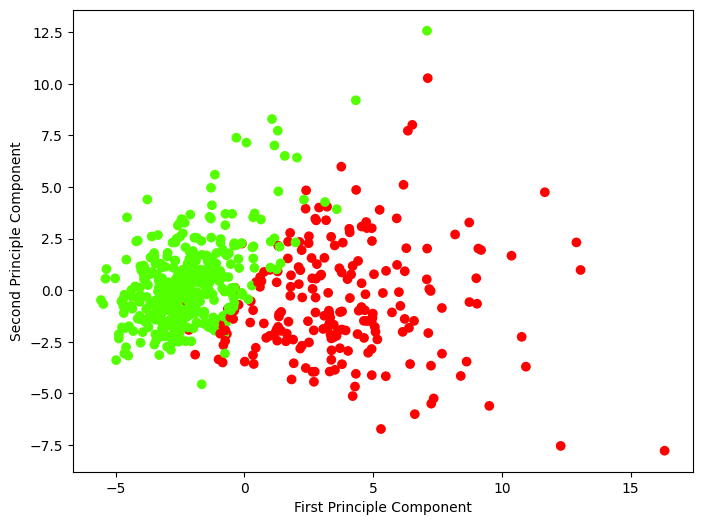

In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_breast_cancer
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

cancer = load_breast_cancer()
cancer.keys()
df = pd.DataFrame(cancer['data'],
                  columns=cancer['feature_names'])
## Standardize features by removing the mean and scaling 
# to unit variance
scaler = StandardScaler()
scaler.fit(df)
scaled_data = scaler.transform(df)
## dimensionality reduction to 16 
pca1 = PCA(n_components=16)
pca1.fit(scaled_data)
z1 = pca1.transform(scaled_data)
print(pca1.explained_variance_ratio_.cumsum())

## Visualizing data in 2D
pca = PCA(n_components=2)
pca.fit(scaled_data)
z = pca.transform(scaled_data)
plt.figure(figsize=(8,6))
plt.scatter(z[:,0],z[:,1],c=cancer['target'],cmap='prism')
plt.xlabel('First Principle Component')
plt.ylabel('Second Principle Component')